Import Necessary Libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import class_likelihood_ratios
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

Read The Dataset



In [7]:
df= pd.read_csv("movie_ratings_dataset.csv")

In [8]:
df.head(15)

,Genre,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Has_Famous_Producer,Num_Awards_Won,Marketing_Spend_MillionUSD,Is_Sequel,Rating_Category
0,Sci-Fi,5.80,134.63,141.0,NaN,1.0,2.72,No,9.0,25.48,No,Excellent
1,Action,2.27,220.47,98.0,2006.0,1.0,3.46,Yes,17.0,9.13,Yes,Excellent
2,Horror,1.23,52.79,160.0,2010.0,2.0,NaN,NaN,43.0,6.16,No,Excellent
3,Action,8.17,86.41,153.0,2022.0,4.0,5.21,NaN,7.0,2.99,No,Good
4,Romance,6.40,259.57,134.0,1986.0,1.0,8.72,Yes,25.0,0.89,No,Excellent
5,Horror,7.40,265.65,NaN,2024.0,3.0,4.08,Yes,NaN,43.91,No,Good
6,Horror,3.73,14.44,NaN,1983.0,1.0,3.40,No,23.0,40.45,No,Average
7,Sci-Fi,5.59,51.26,129.0,1993.0,4.0,NaN,No,2.0,28.39,Yes,Poor
8,Drama,7.72,36.12,144.0,2021.0,NaN,9.20,No,37.0,49.94,No,Average
9,Comedy,5.16,54.73,82.0,2021.0,3.0,1.26,Yes,1.0,47.65,Yes,Excellent


Summarize the data (Visualize the Dataset with Null Values, Data Types and Correlation)

In [9]:
df

,Genre,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Has_Famous_Producer,Num_Awards_Won,Marketing_Spend_MillionUSD,Is_Sequel,Rating_Category
0,Sci-Fi,5.80,134.63,141.0,NaN,1.0,2.72,No,9.0,25.48,No,Excellent
1,Action,2.27,220.47,98.0,2006.0,1.0,3.46,Yes,17.0,9.13,Yes,Excellent
2,Horror,1.23,52.79,160.0,2010.0,2.0,NaN,NaN,43.0,6.16,No,Excellent
3,Action,8.17,86.41,153.0,2022.0,4.0,5.21,NaN,7.0,2.99,No,Good
4,Romance,6.40,259.57,134.0,1986.0,1.0,8.72,Yes,25.0,0.89,No,Excellent
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,Drama,3.54,288.86,167.0,2016.0,3.0,6.35,Yes,46.0,17.66,NaN,Excellent
1196,Comedy,NaN,22.49,179.0,1990.0,4.0,8.95,Yes,17.0,10.54,NaN,Average
1197,Comedy,2.07,81.23,108.0,2023.0,2.0,9.20,No,46.0,38.61,No,Average
1198,Horror,7.80,24.98,139.0,2001.0,2.0,9.63,No,19.0,8.84,Yes,Poor


In [10]:
df.describe()

,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Num_Awards_Won,Marketing_Spend_MillionUSD
count,1067.000000,1096.000000,1074.000000,1088.000000,1075.000000,1066.000000,1061.000000,1089.000000
mean,5.452624,152.768723,129.401304,2002.330882,2.531163,5.495159,24.113101,24.351947
std,2.600397,85.998943,28.744659,13.068670,1.143236,2.620555,14.464153,14.648245
min,1.010000,1.040000,80.000000,1980.000000,1.000000,1.000000,0.000000,0.000000
25%,3.310000,78.857500,103.000000,1991.000000,1.000000,3.230000,12.000000,11.130000
50%,5.400000,156.060000,130.000000,2002.000000,3.000000,5.470000,24.000000,24.430000
75%,7.690000,226.017500,154.000000,2014.000000,4.000000,7.820000,37.000000,37.160000
max,10.000000,299.730000,179.000000,2024.000000,4.000000,10.000000,49.000000,49.980000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Genre                       1071 non-null   object 
 1   Director_Popularity         1067 non-null   float64
 2   Budget_MillionUSD           1096 non-null   float64
 3   Runtime_Minutes             1074 non-null   float64
 4   Release_Year                1088 non-null   float64
 5   Num_Main_Actors             1075 non-null   float64
 6   Avg_Actor_Popularity        1066 non-null   float64
 7   Has_Famous_Producer         1071 non-null   object 
 8   Num_Awards_Won              1061 non-null   float64
 9   Marketing_Spend_MillionUSD  1089 non-null   float64
 10  Is_Sequel                   1083 non-null   object 
 11  Rating_Category             1200 non-null   object 
dtypes: float64(8), object(4)
memory usage: 112.6+ KB


Total Row & Column in the Dataset

In [12]:
df.shape

(1200, 12)

Row Number

In [ ]:
df.shape[0]

1200

Column Number

In [ ]:
df.shape[1]

12

None or Missing Values

In [13]:
df.isnull()

,Genre,Director_Popularity,Budget_MillionUSD,Runtime_Minutes,Release_Year,Num_Main_Actors,Avg_Actor_Popularity,Has_Famous_Producer,Num_Awards_Won,Marketing_Spend_MillionUSD,Is_Sequel,Rating_Category
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,False,False,False,False,False,False,False,False,False,False,True,False
1196,False,True,False,False,False,False,False,False,False,False,True,False
1197,False,False,False,False,False,False,False,False,False,False,False,False
1198,False,False,False,False,False,False,False,False,False,False,False,False


Total Count of Missing or None Values

In [14]:
count=df.isnull().sum()
print(count)

Genre                         129
Director_Popularity           133
Budget_MillionUSD             104
Runtime_Minutes               126
Release_Year                  112
Num_Main_Actors               125
Avg_Actor_Popularity          134
Has_Famous_Producer           129
Num_Awards_Won                139
Marketing_Spend_MillionUSD    111
Is_Sequel                     117
Rating_Category                 0
dtype: int64


Count the Frequency of each Category

In [15]:
print(df['Director_Popularity'].value_counts())

Director_Popularity
3.02    7
1.17    6
3.31    6
5.04    5
9.54    5
       ..
5.79    1
8.11    1
6.41    1
7.72    1
7.40    1
Name: count, Length: 626, dtype: int64


Count the Frequency of each Category with Null Values

In [ ]:
print(df['Director_Popularity'].value_counts(dropna=False))

Director_Popularity
NaN     133
3.02      7
1.17      6
3.31      6
9.54      5
       ... 
5.79      1
8.11      1
6.41      1
7.72      1
7.40      1
Name: count, Length: 627, dtype: int64


Proportion of the Frequency

In [16]:
print(df['Director_Popularity'].value_counts(normalize=True))

Director_Popularity
3.02    0.006560
1.17    0.005623
3.31    0.005623
5.04    0.004686
9.54    0.004686
          ...   
5.79    0.000937
8.11    0.000937
6.41    0.000937
7.72    0.000937
7.40    0.000937
Name: proportion, Length: 626, dtype: float64


Visulize the Distribution of Categorical Data

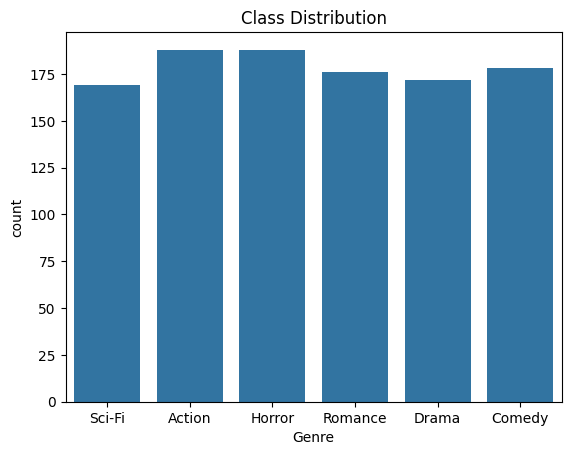

In [17]:
sns.countplot(x = 'Genre', data = df)
plt.title('Class Distribution')
plt.show()

Pairwise Relationship Plot between Numerical Columns in the DataFrame.

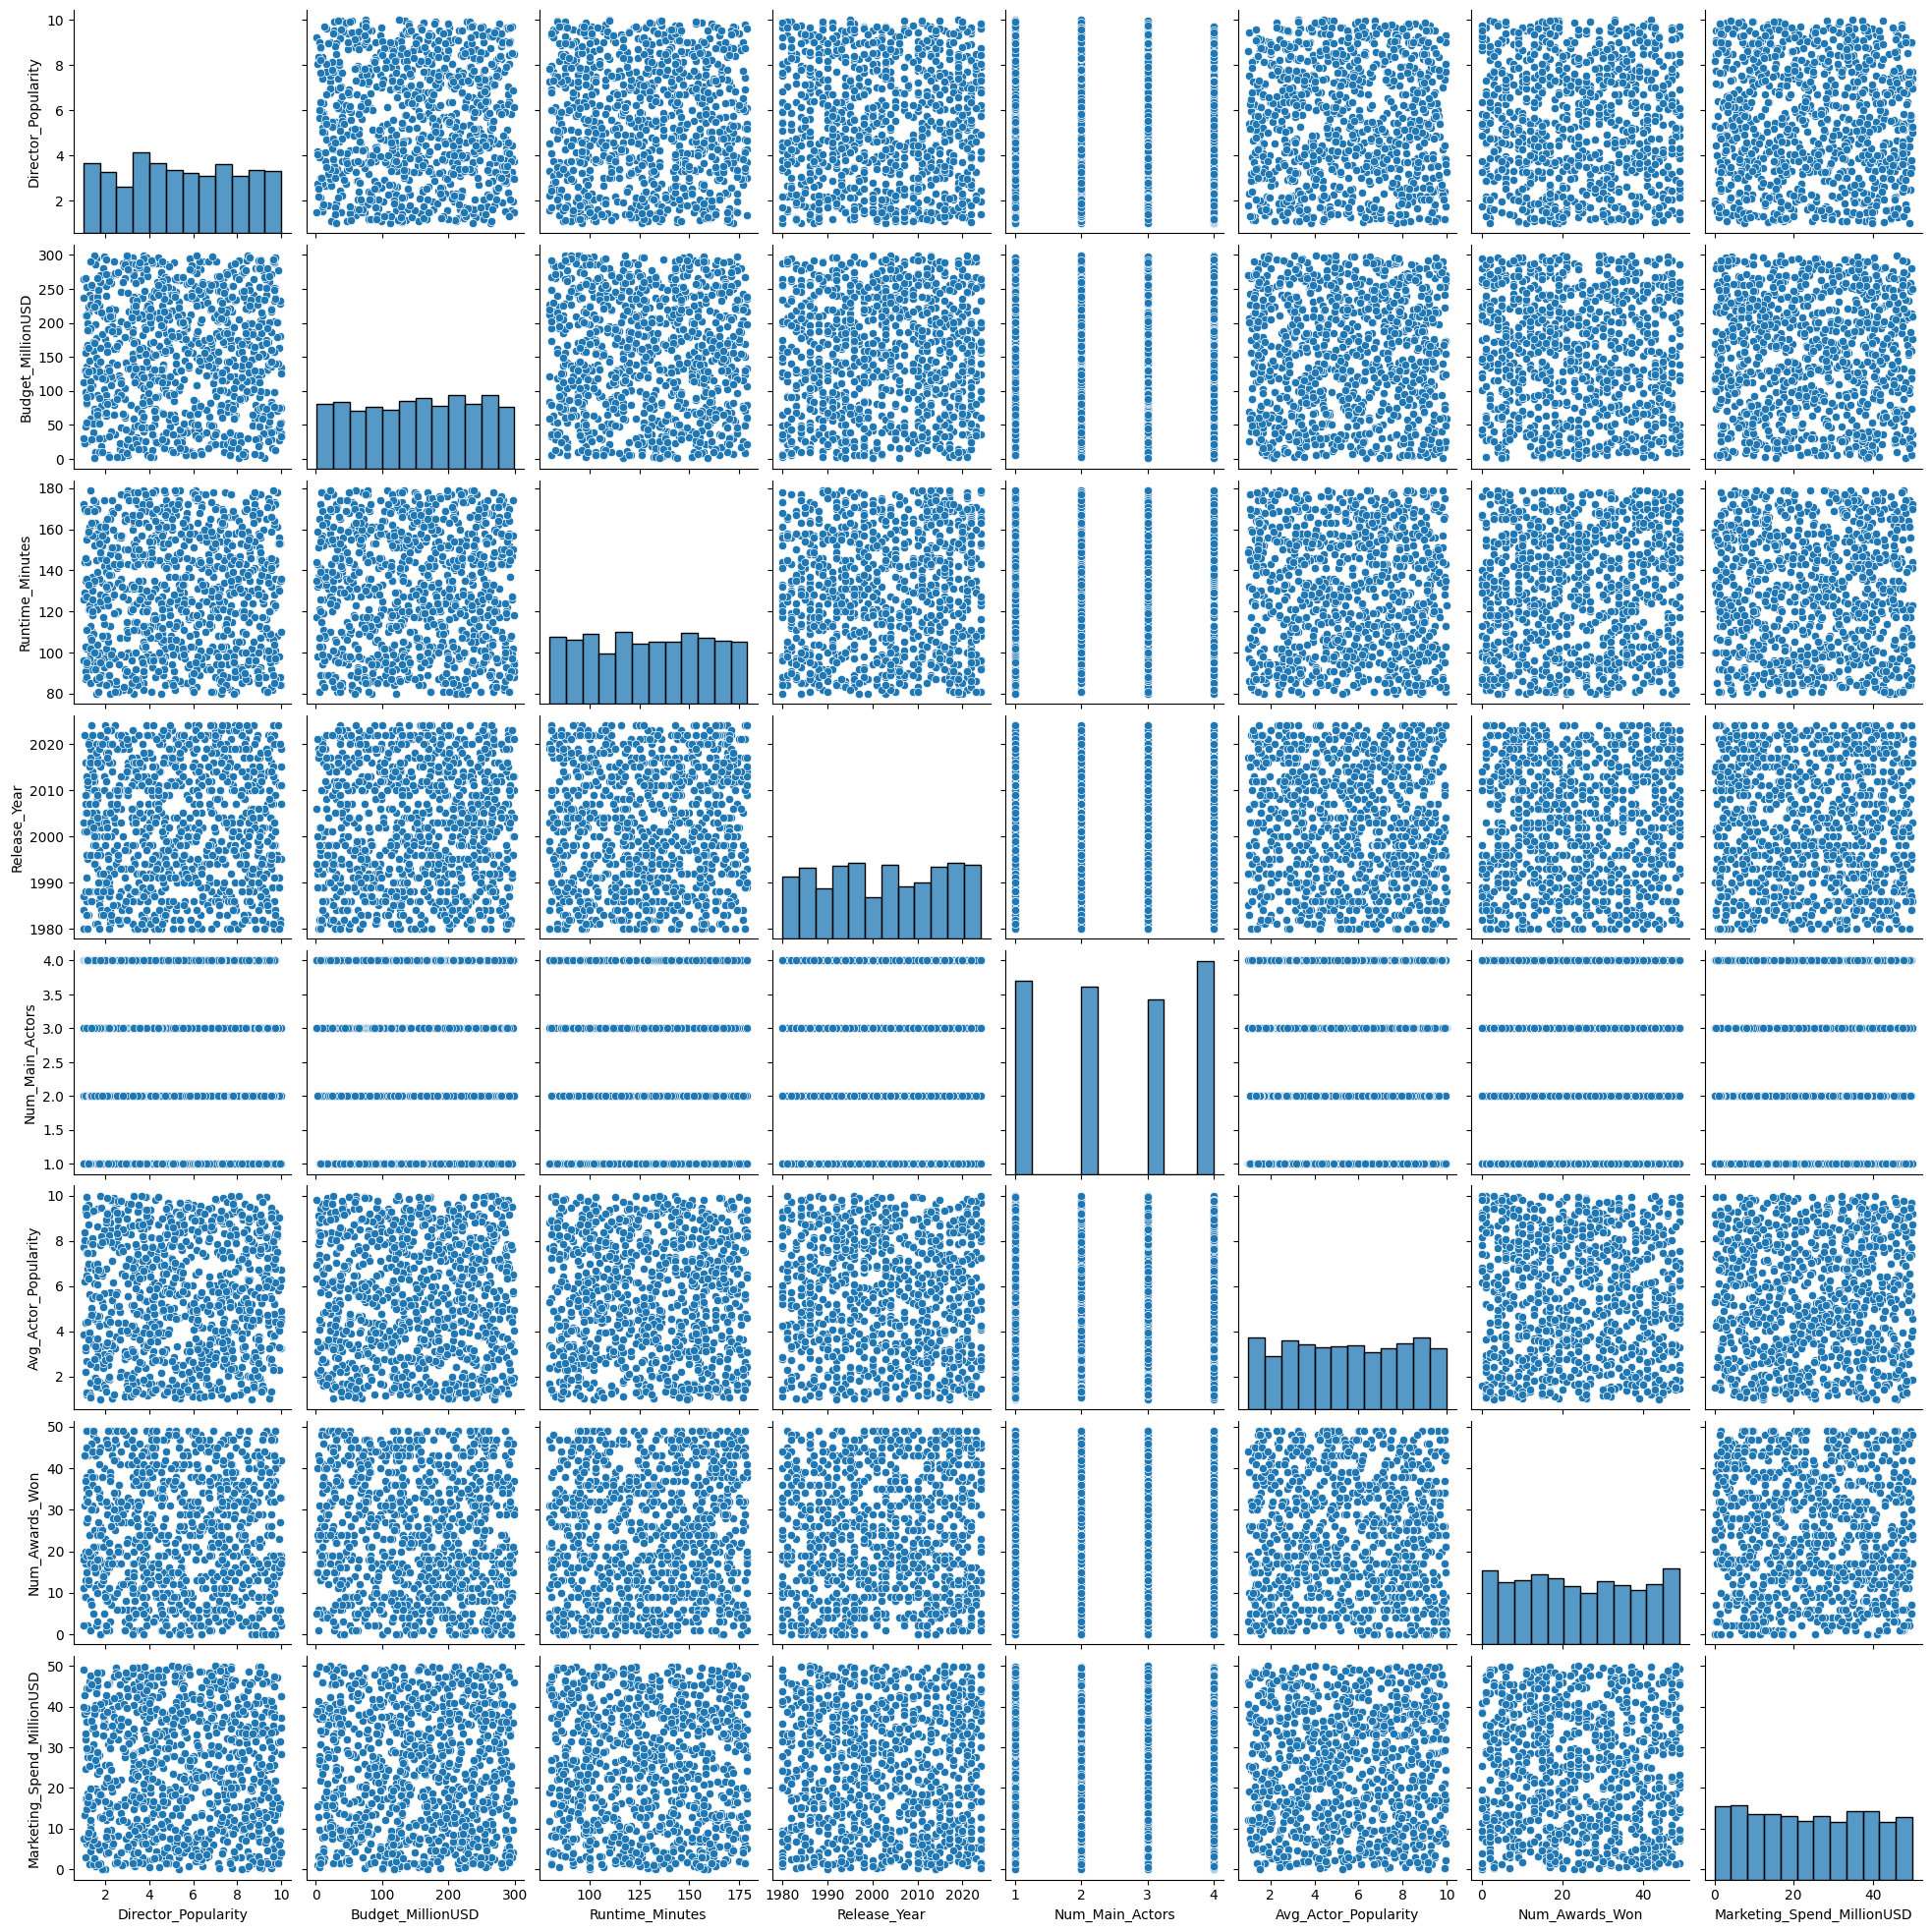

In [18]:
sns.pairplot(df)

Dataset Pre-Processing

In [ ]:
p=df.drop(columns='Genre')
q=df['Genre']

In [ ]:
label_encoder=LabelEncoder()
q=label_encoder.fit_transform(q)

In [ ]:
categorical_features = p.select_dtypes(include = ['object']).columns
transform_column = ColumnTransformer(transformers = [('OneHotEncoder', OneHotEncoder(), categorical_features)], remainder = 'passthrough')
p = transform_column.fit_transform(p)

Dataset  Splitting & Scaling

In [4]:
p_train, p_test, q_train, q_test=train_test_split(p,q, test_size=0.3, random_state=1, stratify=q)

NameError: name 'p' is not defined

In [ ]:
scaler=StandardScaler()
p_train=scaler.fit_transform(p_train)
p_test=scaler.fit_transform(p_test)

Model Training And Testing

KNN

In [ ]:
imputer = SimpleImputer(strategy='mean')
p_train_imputed = imputer.fit_transform(p_train)
p_test_imputed = imputer.transform(p_test)

knn_model = KNeighborsClassifier()
knn_model.fit(p_train_imputed, q_train)

KNeighborsClassifier()

In [ ]:
knn_prediction=knn_model.predict(p_test_imputed)
accuracy_score_of_knn=accuracy_score(q_test, knn_prediction)

print(f'KNN Accuracy: {accuracy_score_of_knn * 100:.2f}%')

precision_of_knn, recall_of_knn, _, _ = precision_recall_fscore_support(q_test, knn_prediction, average = 'weighted')
print(f'KNN Precision: {precision_of_knn:.2f}, KNN Recall: {recall_of_knn:.2f}')
classify_report = classification_report(q_test, knn_prediction)

print("Classification Report:\n", classify_report)

KNN Accuracy: 13.33%
KNN Precision: 0.12, KNN Recall: 0.13
Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.29      0.20        56
           1       0.15      0.15      0.15        53
           2       0.08      0.08      0.08        52
           3       0.16      0.18      0.17        56
           4       0.12      0.11      0.12        53
           5       0.11      0.06      0.08        51
           6       0.06      0.03      0.04        39

    accuracy                           0.13       360
   macro avg       0.12      0.13      0.12       360
weighted avg       0.12      0.13      0.12       360



KNN Confusion Matrix

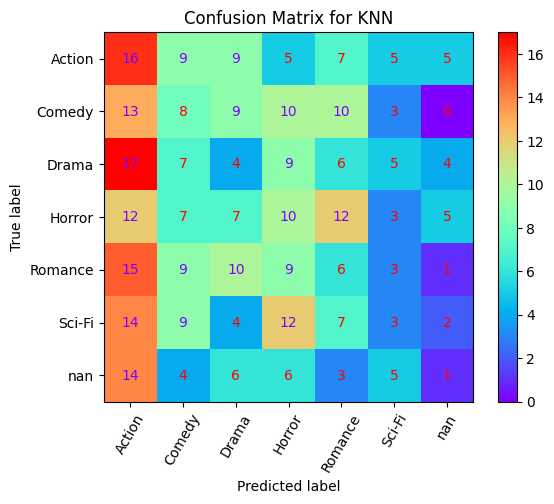

In [ ]:
confusion_matrix_of_knn=confusion_matrix(q_test, knn_prediction)
display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_of_knn, display_labels = label_encoder.classes_)
display.plot(cmap = plt.cm.rainbow)
plt.xticks(rotation = 60)
plt.title('Confusion Matrix for KNN')
plt.show()

Decision Tree

In [ ]:
decision_tree_model = DecisionTreeClassifier(random_state = 1)
decision_tree_model.fit(p_train, q_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
decision_tree_prediction= decision_tree_model.predict(p_test)

accuracy_score_of_decision_tree = accuracy_score(q_test, decision_tree_prediction)
print(f'Decision Tree Accuracy: {accuracy_score_of_decision_tree * 100:.2f}%')

precision_of_decision_tree, recall_of_decision_tree, _, _ = precision_recall_fscore_support(q_test, decision_tree_prediction, average = 'weighted', zero_division=1)
print(f'Decision Tree Precision: {precision_of_decision_tree:.2f}, Decision Tree Recall: {recall_of_decision_tree:.2f}')

classify_report= classification_report(q_test, decision_tree_prediction)

print("Classification Report:\n", classify_report)

Decision Tree Accuracy: 14.44%
Decision Tree Precision: 0.15, Decision Tree Recall: 0.14
Classification Report:
               precision    recall  f1-score   support

           0       0.16      0.16      0.16        56
           1       0.20      0.19      0.20        53
           2       0.09      0.10      0.09        52
           3       0.15      0.16      0.16        56
           4       0.22      0.19      0.20        53
           5       0.13      0.12      0.12        51
           6       0.07      0.08      0.07        39

    accuracy                           0.14       360
   macro avg       0.15      0.14      0.14       360
weighted avg       0.15      0.14      0.15       360



Decision Tree Confusion Matrix

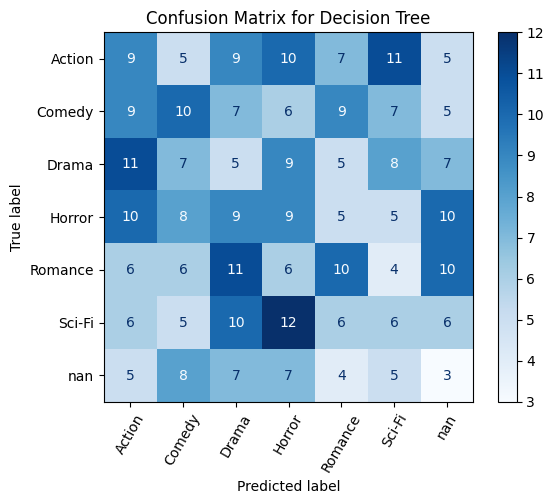

In [ ]:
confusion_matrix_of_decision_tree = confusion_matrix(q_test, decision_tree_prediction)
display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_of_decision_tree, display_labels = label_encoder.classes_)
display.plot(cmap = plt.cm.Blues)
plt.xticks(rotation = 60)
plt.title('Confusion Matrix for Decision Tree')
plt.show()

Logistic Regression

In [ ]:
imputer = SimpleImputer(strategy='mean')
p_train_imputed = imputer.fit_transform(p_train)
p_test_imputed = imputer.transform(p_test)

logistic_regression_model=LogisticRegression(solver = 'lbfgs')
logistic_regression_model.fit(p_train_imputed, q_train)

LogisticRegression()

In [ ]:
logistic_regression_prediction=logistic_regression_model.predict(p_test_imputed)
accuracy_score_of_logistic_regression=accuracy_score(q_test, logistic_regression_prediction)
print(f'Logistic Regression Accuracy: {accuracy_score_of_logistic_regression * 100:.2f}%')

precision_of_logistic_regression, recall_of_logistic_regression, _, _ = precision_recall_fscore_support(q_test,logistic_regression_prediction, average = 'weighted')
print(f'Logistic Regression Precision: {precision_of_logistic_regression:.2f}, Logistic Regression Recall: {recall_of_logistic_regression:.2f}')

classify_report= classification_report(q_test, logistic_regression_prediction)

print("Classification Report:\n", classify_report)

Logistic Regression Accuracy: 13.06%
Logistic Regression Precision: 0.12, Logistic Regression Recall: 0.13
Classification Report:
               precision    recall  f1-score   support

           0       0.11      0.14      0.13        56
           1       0.16      0.15      0.16        53
           2       0.05      0.04      0.04        52
           3       0.14      0.20      0.16        56
           4       0.15      0.15      0.15        53
           5       0.19      0.20      0.19        51
           6       0.00      0.00      0.00        39

    accuracy                           0.13       360
   macro avg       0.11      0.13      0.12       360
weighted avg       0.12      0.13      0.12       360



Logistic Regression Confusion Matrix

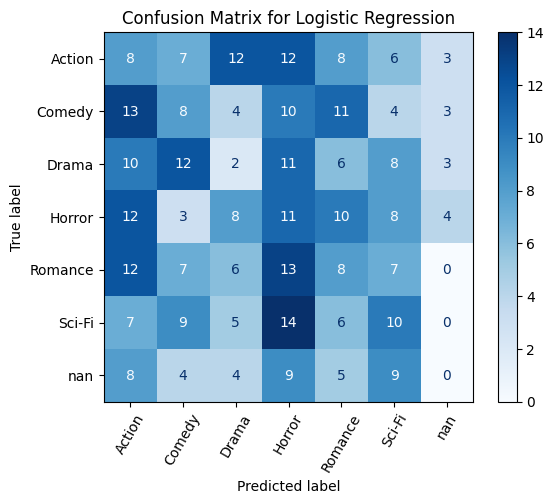

In [ ]:
confusion_matrix_of_logistic_regression = confusion_matrix(q_test, logistic_regression_prediction)
display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_of_logistic_regression, display_labels = label_encoder.classes_)
display.plot(cmap = plt.cm.Blues)
plt.xticks(rotation=60)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

Accuracy Comparison

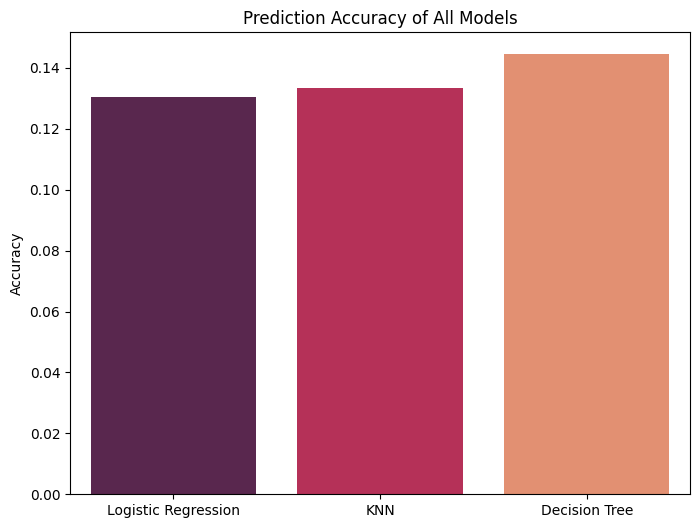

In [ ]:
model_names = ['Logistic Regression', 'KNN', 'Decision Tree']
accuracies = [accuracy_score_of_logistic_regression, accuracy_score_of_knn, accuracy_score_of_decision_tree]
plt.figure(figsize = (8, 6))
sns.barplot(x = model_names, y = accuracies, hue = model_names, dodge = False, palette = 'rocket', legend = False)
plt.title('Prediction Accuracy of All Models')
plt.ylabel('Accuracy')
plt.show()

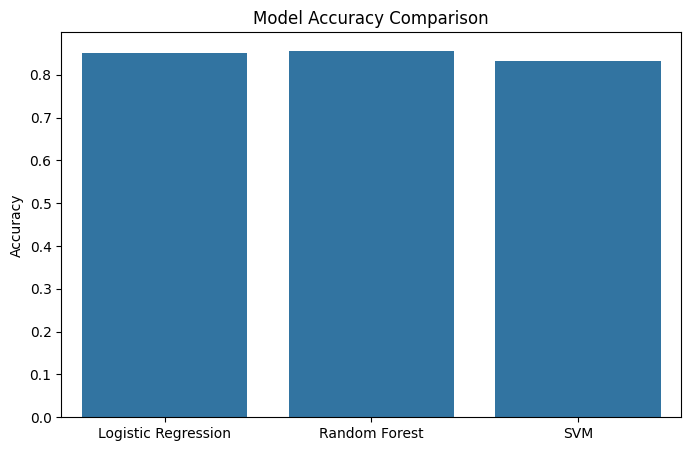

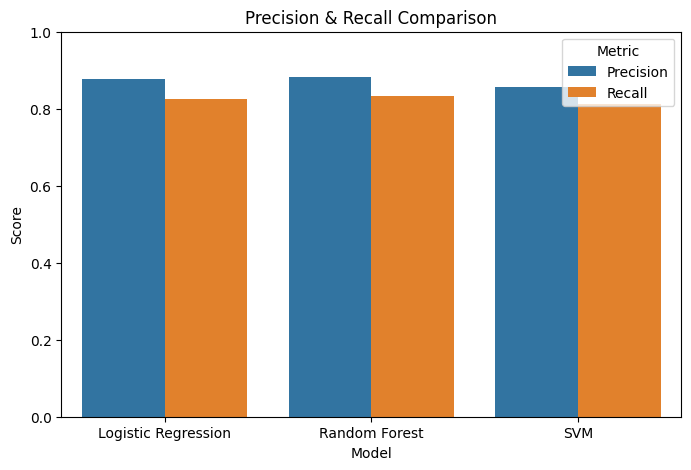

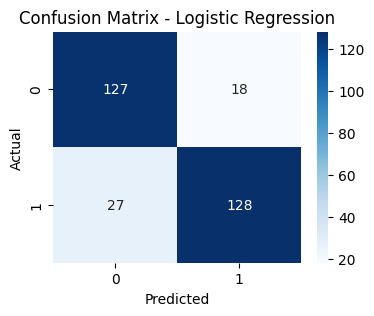

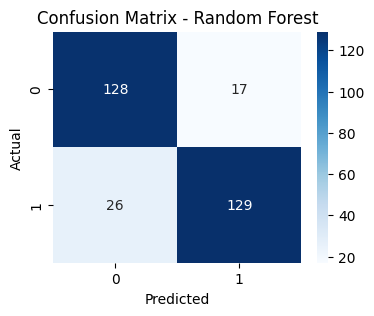

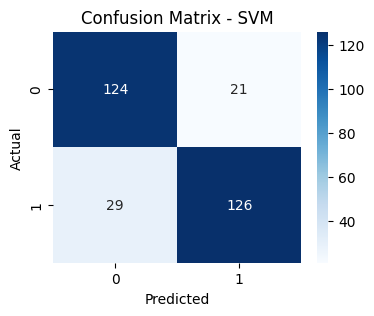

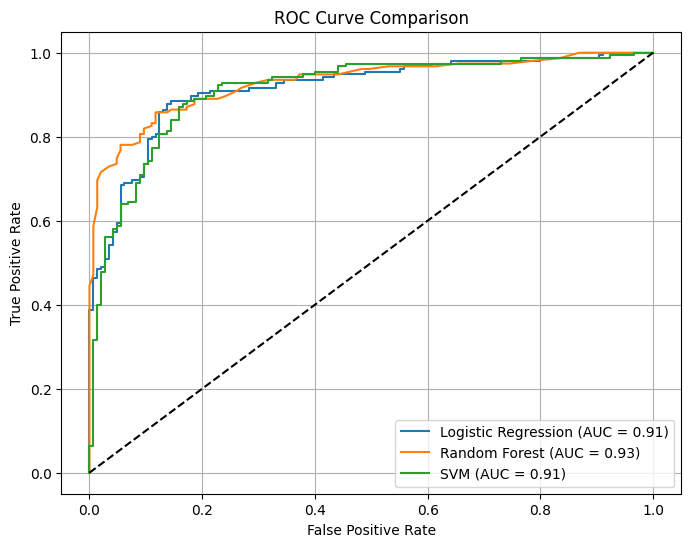

                     Model        R2           MSE         MAE
0        Linear Regression  0.995563     90.529022    7.421325
1  Random Forest Regressor  0.773729   4616.833742   50.849318
2                      SVR  0.084658  18676.670213  106.162736


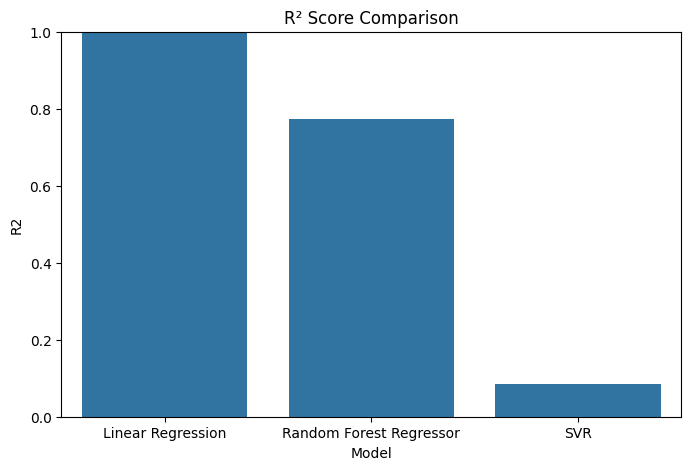

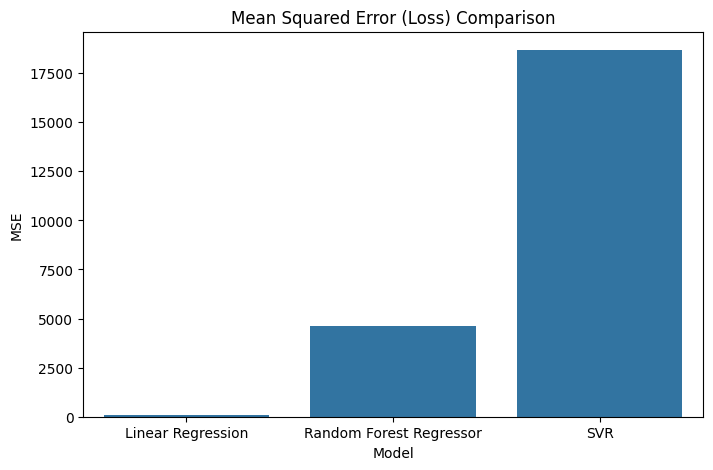

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

# ========== Classification Analysis ==========

# Generate synthetic classification data
X_clf, y_clf = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.3, random_state=42)

# Define classification models
clf_models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

clf_results = []

# Train and evaluate classifiers
for name, model in clf_models.items():
    model.fit(X_train_clf, y_train_clf)
    y_pred = model.predict(X_test_clf)
    y_proba = model.predict_proba(X_test_clf)[:, 1]

    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    auc = roc_auc_score(y_test_clf, y_proba)
    cm = confusion_matrix(y_test_clf, y_pred)

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "AUC": auc,
        "Confusion Matrix": cm,
        "y_proba": y_proba
    })

# Plot accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(x=[r['Model'] for r in clf_results], y=[r['Accuracy'] for r in clf_results])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Plot precision and recall comparison
df_clf_metrics = pd.DataFrame(clf_results)
df_plot = df_clf_metrics[["Model", "Precision", "Recall"]].melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(8, 5))
sns.barplot(data=df_plot, x="Model", y="Score", hue="Metric")
plt.title("Precision & Recall Comparison")
plt.ylim(0, 1)
plt.show()

# Plot confusion matrices
for res in clf_results:
    plt.figure(figsize=(4, 3))
    sns.heatmap(res['Confusion Matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {res['Model']}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot ROC curves
plt.figure(figsize=(8, 6))
for res in clf_results:
    fpr, tpr, _ = roc_curve(y_test_clf, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC = {res['AUC']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# ========== Regression Analysis ==========

# Generate synthetic regression data
X_reg, y_reg = make_regression(n_samples=500, n_features=10, noise=10, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Define regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(),
    "SVR": SVR()
}

reg_results = []

for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred = model.predict(X_test_reg)

    r2 = r2_score(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)

    reg_results.append({
        "Model": name,
        "R2": r2,
        "MSE": mse,
        "MAE": mae
    })

# Display regression results
df_reg = pd.DataFrame(reg_results)
print(df_reg)

# Plot R2 score comparison
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2", data=df_reg)
plt.title("R² Score Comparison")
plt.ylim(0, 1)
plt.show()

# Plot Loss (MSE) comparison
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="MSE", data=df_reg)
plt.title("Mean Squared Error (Loss) Comparison")
plt.show()



KNN Accuracy: 29.44%
KNN Precision: 0.29, Recall: 0.29
Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.41      0.34        88
           1       0.35      0.38      0.36        91
           2       0.27      0.25      0.26        97
           3       0.25      0.13      0.17        84

    accuracy                           0.29       360
   macro avg       0.29      0.29      0.28       360
weighted avg       0.29      0.29      0.28       360



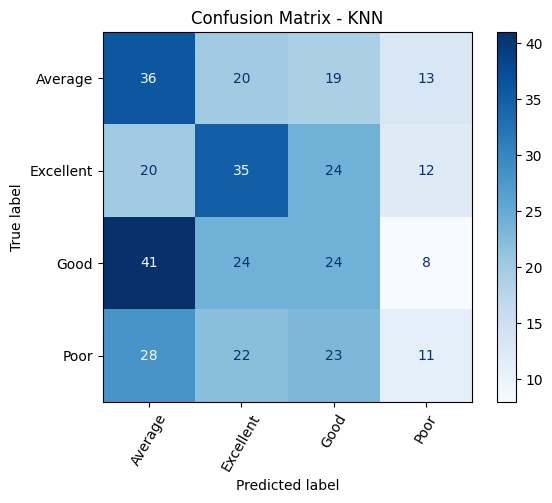

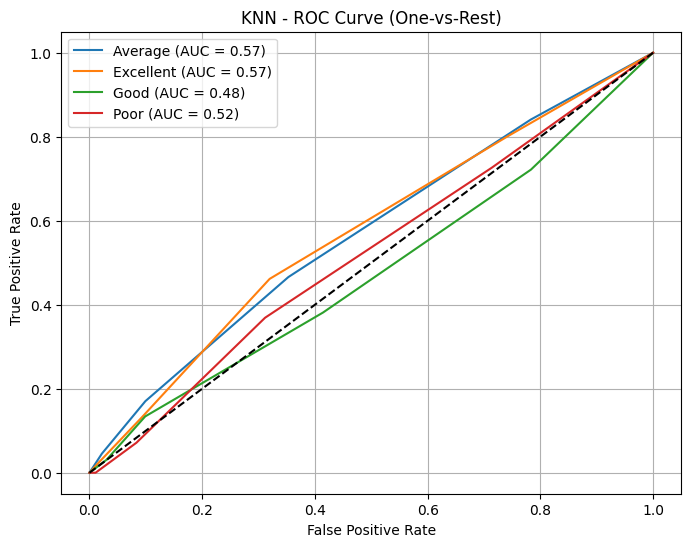


Decision Tree Accuracy: 23.06%
Decision Tree Precision: 0.23, Recall: 0.23
Classification Report:
               precision    recall  f1-score   support

           0       0.22      0.25      0.24        88
           1       0.23      0.26      0.24        91
           2       0.17      0.13      0.15        97
           3       0.30      0.29      0.29        84

    accuracy                           0.23       360
   macro avg       0.23      0.23      0.23       360
weighted avg       0.23      0.23      0.23       360



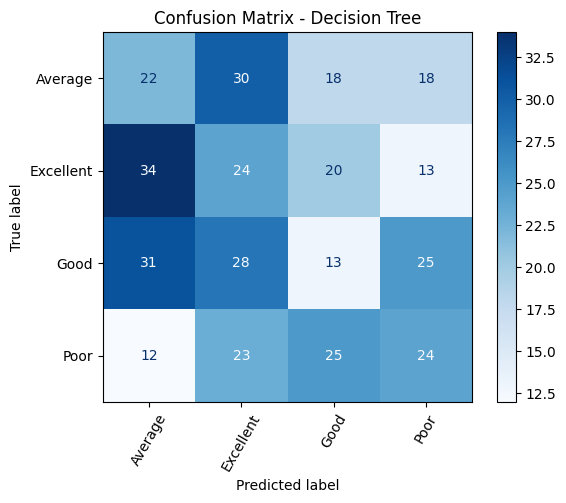

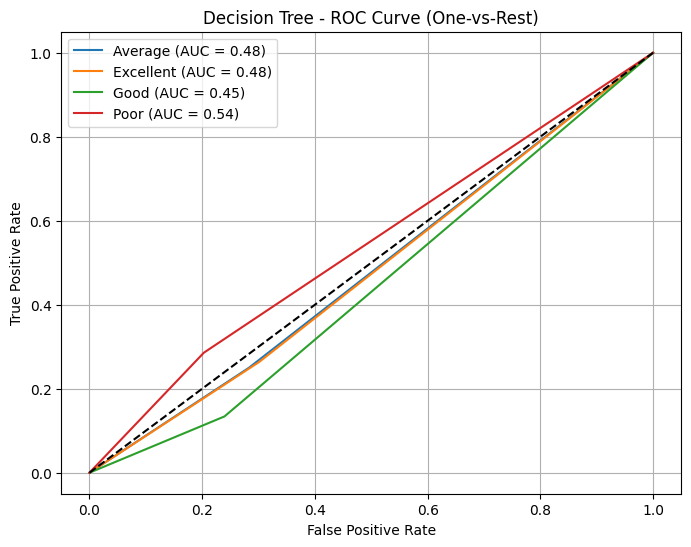

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Accuracy: 25.56%
Logistic Regression Precision: 0.25, Recall: 0.26
Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.24      0.25        88
           1       0.29      0.32      0.30        91
           2       0.24      0.35      0.29        97
           3       0.22      0.10      0.13        84

    accuracy                           0.26       360
   macro avg       0.25      0.25      0.24       360
weighted avg       0.25      0.26      0.24       360



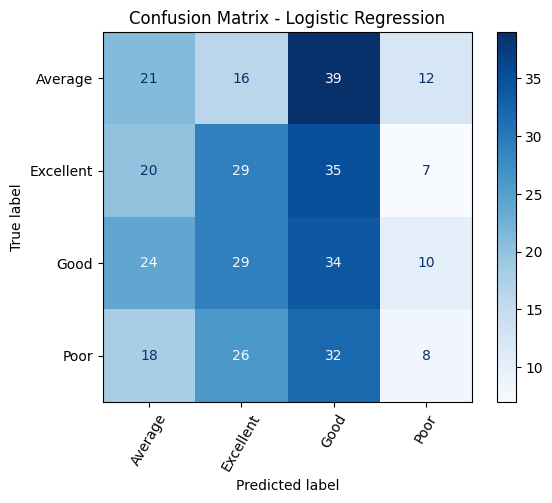

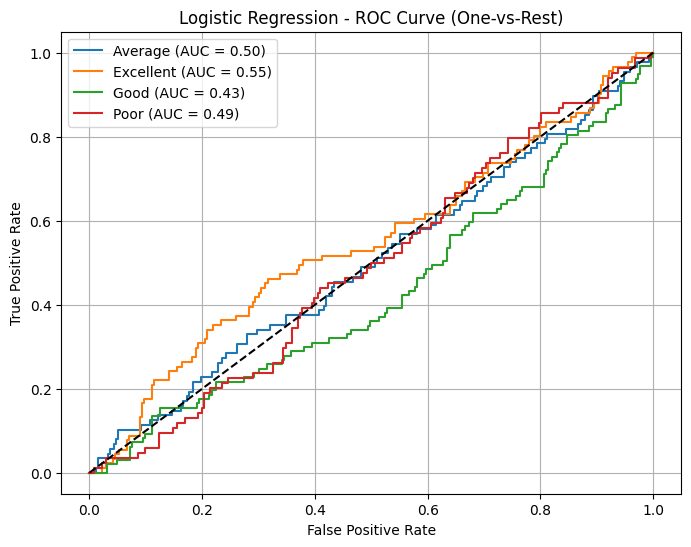


------ Regression Analysis on Genre (numeric) ------
Linear Regression R² Score: -0.020
Linear Regression MSE: 1.229
Linear Regression MAE: 0.982


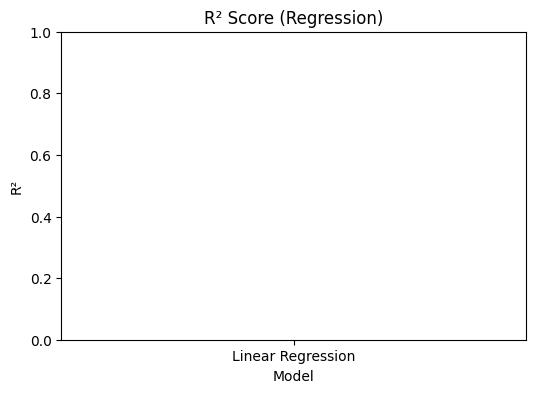

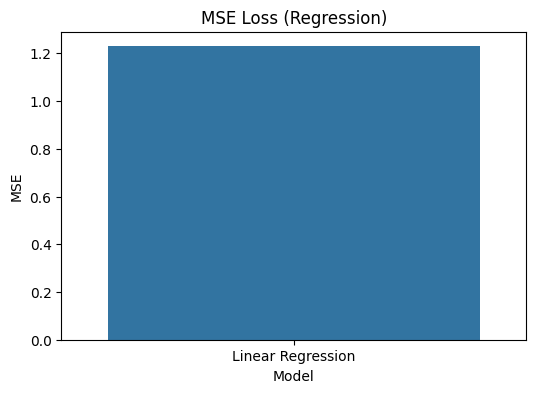

In [20]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay,
    r2_score, mean_squared_error, mean_absolute_error
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize

# ------------------ Preprocessing ------------------

p = df.drop(columns='Rating_Category')
q = df['Rating_Category']

label_encoder = LabelEncoder()
q_encoded = label_encoder.fit_transform(q)
class_names = label_encoder.classes_

categorical_features = p.select_dtypes(include=['object']).columns
transform_column = ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(), categorical_features)],
                                     remainder='passthrough')
p = transform_column.fit_transform(p)

p_train, p_test, q_train, q_test = train_test_split(p, q_encoded, test_size=0.3, random_state=1, stratify=q_encoded)

scaler = StandardScaler()
p_train = scaler.fit_transform(p_train)
p_test = scaler.transform(p_test)

imputer = SimpleImputer(strategy='mean')
p_train = imputer.fit_transform(p_train)
p_test = imputer.transform(p_test)

# ------------------ Classification Models ------------------

def train_classification_model(name, model):
    model.fit(p_train, q_train)
    y_pred = model.predict(p_test)
    accuracy = accuracy_score(q_test, y_pred)
    precision, recall, _, _ = precision_recall_fscore_support(q_test, y_pred, average='weighted', zero_division=1)

    print(f'\n{name} Accuracy: {accuracy * 100:.2f}%')
    print(f'{name} Precision: {precision:.2f}, Recall: {recall:.2f}')
    print("Classification Report:\n", classification_report(q_test, y_pred))

    cm = confusion_matrix(q_test, y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    display.plot(cmap=plt.cm.Blues)
    plt.xticks(rotation=60)
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # --------- AUC & ROC (Multiclass One-vs-Rest) ---------
    # Binarize output for multiclass ROC
    q_test_bin = label_binarize(q_test, classes=np.unique(q_encoded))
    y_score = model.predict_proba(p_test)

    # ROC and AUC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(q_test_bin[:, i], y_score[:, i])
        roc_auc[i] = roc_auc_score(q_test_bin[:, i], y_score[:, i])

    # Plot ROC Curves
    plt.figure(figsize=(8, 6))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'{name} - ROC Curve (One-vs-Rest)')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)
    plt.show()


# KNN
knn_model = KNeighborsClassifier()
train_classification_model("KNN", knn_model)

# Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=1)
train_classification_model("Decision Tree", decision_tree_model)

# Logistic Regression
logistic_regression_model = LogisticRegression(solver='lbfgs', max_iter=500, multi_class='ovr')
train_classification_model("Logistic Regression", logistic_regression_model)


# ------------------ Regression Model ------------------
# Treat Genre as numeric for regression analysis (label encoded already)
print("\n------ Regression Analysis on Genre (numeric) ------")

# Linear Regression (as an example)
reg_model = LinearRegression()
reg_model.fit(p_train, q_train)
q_pred = reg_model.predict(p_test)

r2 = r2_score(q_test, q_pred)
mse = mean_squared_error(q_test, q_pred)
mae = mean_absolute_error(q_test, q_pred)

print(f"Linear Regression R² Score: {r2:.3f}")
print(f"Linear Regression MSE: {mse:.3f}")
print(f"Linear Regression MAE: {mae:.3f}")

# Plot R² & Loss
results_df = pd.DataFrame([{
    "Model": "Linear Regression",
    "R²": r2,
    "MSE": mse,
    "MAE": mae
}])

plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="R²", data=results_df)
plt.title("R² Score (Regression)")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="MSE", data=results_df)
plt.title("MSE Loss (Regression)")
plt.show()
